Loading necessary libraries

## Contiguity Weights

In [ ]:

import pandas
import rioxarray
import contextily
import geopandas
import rioxarray
import seaborn
import pandas
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from pysal.lib import cg as geometry
from pysal.lib import weights
import pathlib
import os   

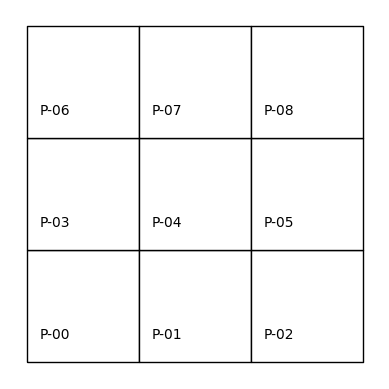

In [30]:
# Get points in a grid
l = np.arange(3)
xs, ys = np.meshgrid(l, l)
# Set up store
polys = []
# Generate polygons
for x, y in zip(xs.flatten(), ys.flatten()):
    poly = Polygon([(x, y), (x + 1, y), (x + 1, y + 1), (x, y + 1)])
    polys.append(poly)
# Convert to GeoSeries
polys = geopandas.GeoSeries(polys)
gdf = geopandas.GeoDataFrame(
    {
        "geometry": polys,
        "id": ["P-%s" % str(i).zfill(2) for i in range(len(polys))],
    }
)

# Plot grid geotable
ax = gdf.plot(facecolor="w", edgecolor="k")

# Loop over each cell and add the text
for x, y, t in zip(
    [p.centroid.x - 0.25 for p in polys],
    [p.centroid.y - 0.25 for p in polys],
    [i for i in gdf["id"]],
):
    plt.text(
        x,
        y,
        t,
        verticalalignment="center",
        horizontalalignment="center",
    )

# Remove axes
ax.set_axis_off()
plt.show()

#### Rook contiguity

/var/folders/b_/785b5fkd03z7drcwj2yt_rwr0000gp/T/ipykernel_58290/179334427.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wr = weights.contiguity.Rook.from_dataframe(gdf)


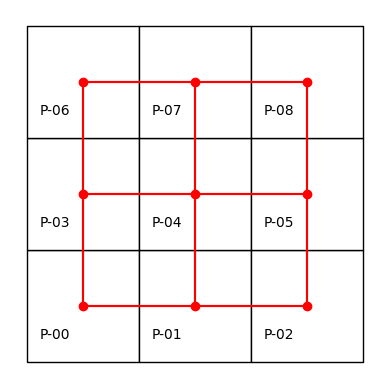

In [31]:
# Build a rook contiguity matrix from a regular 3x3
# lattice stored in a geo-table
wr = weights.contiguity.Rook.from_dataframe(gdf)

# Set up figure
f, ax = plt.subplots(1, 1)
ax.set_aspect('equal')
# Plot grid
gdf.plot(facecolor="w", edgecolor="k", ax=ax)
# Loop over each cell and add the text
for x, y, t in zip(
    [p.centroid.x - 0.25 for p in polys],
    [p.centroid.y - 0.25 for p in polys],
    [i for i in gdf["id"]],
):
    plt.text(
        x,
        y,
        t,
        verticalalignment="center",
        horizontalalignment="center",
    )
# Plot weights connectivity
wr.plot(gdf, color= "r",  ax=ax)
# Remove axes
ax.set_axis_off()

In [32]:
wr.neighbors

{0: [1, 3],
 1: [0, 2, 4],
 2: [1, 5],
 3: [0, 4, 6],
 4: [1, 3, 5, 7],
 5: [8, 2, 4],
 6: [3, 7],
 7: [8, 4, 6],
 8: [5, 7]}

In [33]:
pandas.DataFrame(*wr.full()).astype(int)

,0,1,2,3,4,5,6,7,8
0,0,1,0,1,0,0,0,0,0
1,1,0,1,0,1,0,0,0,0
2,0,1,0,0,0,1,0,0,0
3,1,0,0,0,1,0,1,0,0
4,0,1,0,1,0,1,0,1,0
5,0,0,1,0,1,0,0,0,1
6,0,0,0,1,0,0,0,1,0
7,0,0,0,0,1,0,1,0,1
8,0,0,0,0,0,1,0,1,0


In [34]:
wr.nonzero

24

### Queen contiguity

In [35]:
# Build a queen contiguity matrix from a regular 3x3
# lattice stored in a geo-table
wq = weights.contiguity.Queen.from_dataframe(gdf)
wq.neighbors

/var/folders/b_/785b5fkd03z7drcwj2yt_rwr0000gp/T/ipykernel_58290/736973915.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = weights.contiguity.Queen.from_dataframe(gdf)


{0: [1, 3, 4],
 1: [0, 2, 3, 4, 5],
 2: [1, 4, 5],
 3: [0, 1, 4, 6, 7],
 4: [0, 1, 2, 3, 5, 6, 7, 8],
 5: [1, 2, 4, 7, 8],
 6: [3, 4, 7],
 7: [3, 4, 5, 6, 8],
 8: [4, 5, 7]}

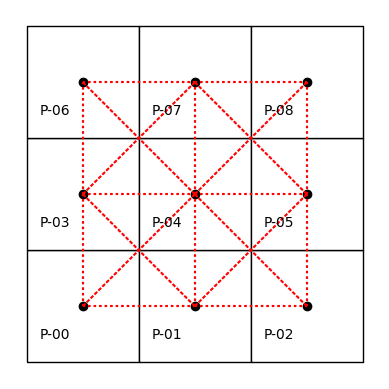

In [36]:
# Set up figure
f, ax = plt.subplots(1, 1, subplot_kw=dict(aspect="equal"))
# Plot grid
gdf.plot(facecolor="w", edgecolor="k", ax=ax)
# Loop over each cell and add the text
for x, y, t in zip(
    [p.centroid.x - 0.25 for p in polys],
    [p.centroid.y - 0.25 for p in polys],
    [i for i in gdf["id"]],
):
    plt.text(
        x,
        y,
        t,
        verticalalignment="center",
        horizontalalignment="center",
    )
# Plot weights connectivity
wq.plot(gdf, edge_kws=dict(color="r", linestyle=":"), ax=ax)
# Remove axes
ax.set_axis_off()

In [37]:
wq.cardinalities

{0: 3, 1: 5, 2: 3, 3: 5, 4: 8, 5: 5, 6: 3, 7: 5, 8: 3}

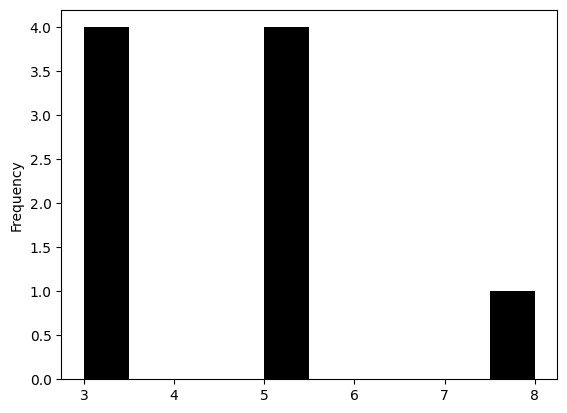

In [38]:
wq.histogram
pandas.Series(wq.cardinalities).plot.hist(color="k");

In [39]:
wq.pct_nonzero

49.382716049382715

### Real-world examples for spatial contiguity

Reading San Diego dataset:

In [8]:
COURSE_DATASETS_PATH = pathlib.Path("./Course-Datasets")
COURSE_DATASETS_PATH.resolve()

NameError: name 'pathlib' is not defined

In [41]:
import os
os.getcwd()

'/Users/Adnan/Siddique/Work-Related/Teaching/ITU/Spatial Data Science/Spring 2025/code-sds-sp2025/Notebooks'

/var/folders/b_/785b5fkd03z7drcwj2yt_rwr0000gp/T/ipykernel_58290/3783134250.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = weights.contiguity.Queen.from_dataframe(san_diego_tracts)


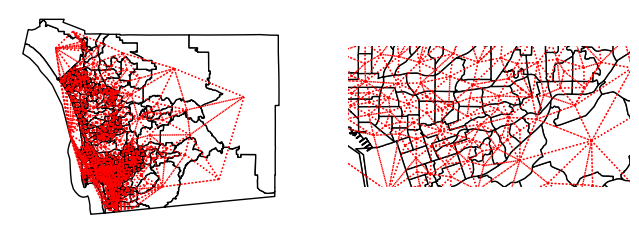

In [ ]:
san_diego_tracts = geopandas.read_file("./Course-Datasets/sandiego_tracts.gpkg")

w_queen = weights.contiguity.Queen.from_dataframe(san_diego_tracts)

# Plot tract geography
f, axs = plt.subplots(1, 2, figsize=(8, 4))
for i in range(2):
    ax = san_diego_tracts.plot(
        edgecolor="k", facecolor="w", ax=axs[i]
    )
    # Plot graph connections
    w_queen.plot(
        san_diego_tracts,
        ax=axs[i],
        edge_kws=dict(color="r", linestyle=":", linewidth=1),
        node_kws=dict(marker=""),
    )
    # Remove the axis
    axs[i].set_axis_off()
axs[1].axis([-13040000, -13020000, 3850000, 3860000]);

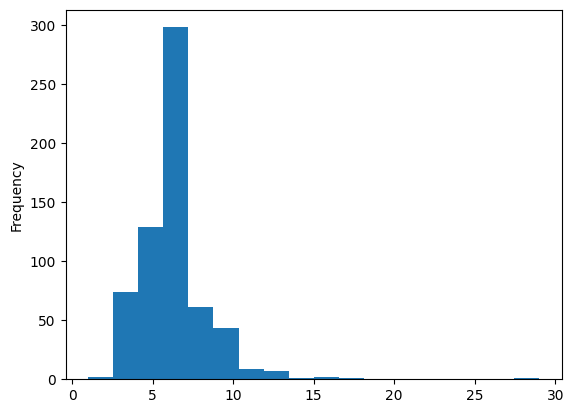

In [43]:
s = pandas.Series(w_queen.cardinalities)
s.plot.hist(bins=s.unique().shape[0]);

In [44]:
help(w_queen)

Help on Queen in module libpysal.weights.contiguity object:

class Queen(libpysal.weights.weights.W)
 |  Queen(polygons, **kw)
 |  
 |  Construct a weights object from a collection of pysal polygons that share at least one vertex.
 |  
 |  Parameters
 |  ----------
 |  polygons    : list
 |                a collection of PySAL shapes to build weights from
 |  ids         : list
 |                a list of names to use to build the weights
 |  **kw        : keyword arguments
 |                optional arguments for :class:`pysal.weights.W`
 |  
 |  See Also
 |  --------
 |  :class:`libpysal.weights.weights.W`
 |  
 |  Method resolution order:
 |      Queen
 |      libpysal.weights.weights.W
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, polygons, **kw)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  ----------------------------------------------------------------------
 |  Class methods defined here:
 |  
 |  from_dataframe

/var/folders/b_/785b5fkd03z7drcwj2yt_rwr0000gp/T/ipykernel_58290/4224238825.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_rook = weights.contiguity.Rook.from_dataframe(san_diego_tracts)


0.8722463385938578


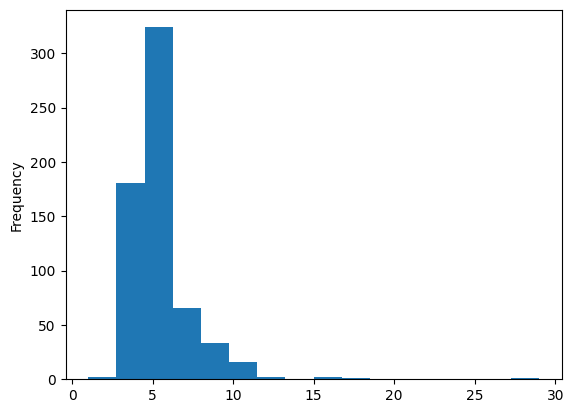

In [45]:
w_rook = weights.contiguity.Rook.from_dataframe(san_diego_tracts)
print(w_rook.pct_nonzero)
s = pandas.Series(w_rook.cardinalities)
s.plot.hist(bins=s.unique().shape[0]);

The cardinality histogram shifts downward due to the increasing sparsity of the weights for the rook case relative to the Queen criterion. Conceptually, this makes sense: all Rook neighbors are also Queen neighbors, since Queen includes neighbors that share an edge; but, not all Queen neighbors are Rook neighbors, since some Queen neighbors only share a point on their boundaries in common.

## Distance Based Weights

In addition to contiguity, we can also define neighbor relations as a function of the distance separating spatial observations.

### K-Nearest Neighbor weights

The first type of distance based weights defines the neighbor set of a particular observation as containing its nearest *k* observations, where the user specifies the value of *k*.
 
The centroids are calculated from the spatial information stored in the GeoDataFrame as we have seen before. Since we are dealing with polygons in this case, pysal uses inter-centroid distances to determine the nearest observations to each polygon.



In [46]:
wk4 = weights.distance.KNN.from_dataframe(san_diego_tracts, k=4)

In [47]:
wk4.histogram

[(4, 628)]

### Kernel Weights

The essence of kernel weights is that the weight between observations *i* and *j* is based on their distance, but it is further modulated by a kernel function with certain properties. pysal implements several kernels. All of them share the properties of distance decay (thus encoding Tobler’s First Law), but may decay at different rates with respect to distance.

In [48]:
w_kernel = weights.distance.Kernel.from_dataframe(gdf)

:question: Like k-nearest neighbor weights, the Kernel weights are based on distances between observations. Whats the difference?

In [49]:
w_kernel.function

'triangular'

In [50]:
# Show the first five values of bandwidths
w_kernel.bandwidth[0:5]

array([[1.0000001],
       [1.0000001],
       [1.0000001],
       [1.0000001],
       [1.0000001]])

The value of the weights will be a function of two main options for kernel weights: choice of kernel function; and the bandwidth. The former controls how distance between *i* and *j* is "modulated" to produce a the weight that goes in *w_{ij}*.

**The bandwidth specifies the distance from each focal unit over which the kernel function is applied. For observations separated by distances larger than the bandwidth, the weights are set to zero.**

Although simple, a fixed bandwidth is not always the best choice. For example, in cases where the density of the observations varies over the study region, using the same threshold anywhere will result in regions with a high density of neighbors while others with observations very sparsely connected. In these situations, an adaptive bandwidth -one which varies by observation and its characteristics- can be preferred.

Adaptive bandwidths are picked again using a K-nearest neighbor rule. A bandwidth for each observation is chosen such that, once the 
k-nearest observation is considered, all the remaining observations have zero weight. To illustrate it, we will use a subset of tracts in our San Diego dataset. First, visualising the centroids, we can see that they are not exactly regularly-spaced, although others do nearly fall into a regular spacing:



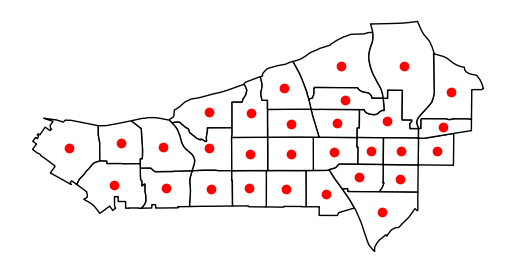

In [51]:
# Create subset of tracts
sub_30 = san_diego_tracts.query("sub_30 == True")
# Plot polygons
ax = sub_30.plot(facecolor="w", edgecolor="k")
# Create and plot centroids
sub_30.head(30).centroid.plot(color="r", ax=ax)
# Remove axis
ax.set_axis_off();

In [ ]:
# Build weights with adaptive bandwidth
w_adaptive = weights.distance.Kernel.from_dataframe(
    sub_30, fixed=False, k=15
)
# Print first five bandwidth values
w_adaptive.bandwidth[:10]

array([[7065.74020822],
       [3577.22591841],
       [2989.74807871],
       [2891.46196945],
       [3965.08354232]])

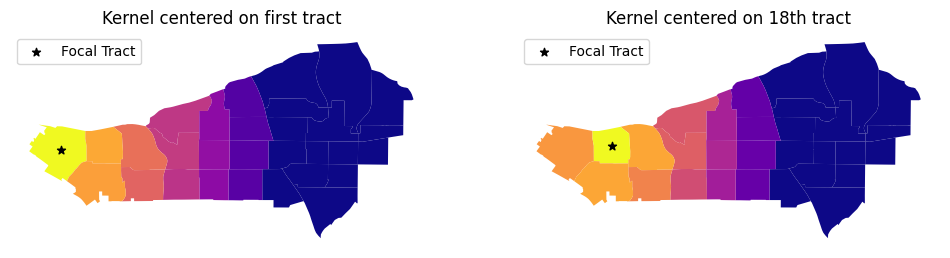

In [53]:
# Create full matrix version of weights
full_matrix, ids = w_adaptive.full()
# Set up figure with two subplots in a row
f, ax = plt.subplots(
    1, 2, figsize=(12, 6), subplot_kw=dict(aspect="equal")
)
# Append weights for first polygon and plot on first subplot
sub_30.assign(weight_0=full_matrix[0]).plot(
    "weight_0", cmap="plasma", ax=ax[0]
)
# Append weights for 18th polygon and plot on first subplot
sub_30.assign(weight_18=full_matrix[17]).plot(
    "weight_18", cmap="plasma", ax=ax[1]
)
# Add centroid of focal tracts
sub_30.iloc[[0], :].centroid.plot(
    ax=ax[0], marker="*", color="k", label="Focal Tract"
)
sub_30.iloc[[17], :].centroid.plot(
    ax=ax[1], marker="*", color="k", label="Focal Tract"
)
# Add titles
ax[0].set_title("Kernel centered on first tract")
ax[1].set_title("Kernel centered on 18th tract")
# Remove axis
[ax_.set_axis_off() for ax_ in ax]
# Add legend
[ax_.legend(loc="upper left") for ax_ in ax];

In [54]:
w_kernel.pct_nonzero

40.74074074074074

### Distance bands and hybrid Weights

In some contexts, it makes sense to draw a circle around each observation and consider as neighbors every other observation that falls within the circle. 


In [55]:
w_bdb = weights.distance.DistanceBand.from_dataframe(
    gdf, 1.5, binary=True)


In [56]:
w_hy = weights.distance.DistanceBand.from_dataframe(
    gdf, 1.5, binary=False
)

/Users/Adnan/miniconda3/envs/sds/lib/python3.9/site-packages/scipy/sparse/_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)


In [57]:
wq.weights[4]

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

In [58]:
w_hy.weights[4]

[0.7071067811865475,
 1.0,
 0.7071067811865475,
 1.0,
 1.0,
 0.7071067811865475,
 1.0,
 0.7071067811865475]

### Great Circle distances

We must make one final curve before leaving the distance based weights. It is important that the calculation of distances between objects takes the curvature of the Earth’s surface into account. This can be done before computing the spatial weights object, by transforming the coordinates of data points into a projected reference system. If this is not possible or convenient, an approximation that considers the curvature implicit in non-projected reference systems (e.g. longitude/latitude) can be a sufficient workaround.

In [ ]:
# ignore curvature of the earth
knn4_bad = weights.distance.KNN.from_shapefile("./Course-Datasets/content/data/texas.shp", k = 4)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/Adnan/Siddique/Work-Related/Teaching/ITU/Spatial Data Science/Course-Datasets/content 2/data/texas.shp'

In [ ]:
radius = geometry.sphere.RADIUS_EARTH_MILES
radius

In [ ]:
knn4 = weights.distance.KNN.from_shapefile(
    "./Course-Datasets/content/data/texas.shp", k=4, radius=radius
)

In [ ]:
knn4[0]

In [ ]:
knn4_bad[0]

## Block Weights

A final type of spatial weight we examine here are block weights. In this case, it is membership in a geographic group that defines the neighbor. Block weights connect every observation in a data set that belong to the same category in a provided list. 

In essence, a block weight structure groups individual observations and considers all members of the group as “near” one another. This means that they then have a value of one for every pair of observations in the same group. Contrariwise, all members not in that group are considered disconnected from any observation within the group, and given a value of zero.


In [ ]:
san_diego_tracts[["GEOID", "state", "county", "tract"]].head()

To build a block weights object, we do not even need spatial data beyond the list of memberships. In this case, we will use the county membership:

In [ ]:
# NOTE: since this is a large dataset, it might take a while to process
w_bl = weights.util.block_weights(
    san_diego_tracts["county"].values,
    ids=san_diego_tracts["GEOID"].values,
)

In [ ]:
"06073000201" in w_bl["06073000100"]

## Set Operations on Weights


Imagine one of our tracts was an island and did not have any neighbors in the contiguity case. This can create issues in the spatial analytics that build on spatial weights, so it is good practice to amend the matrix before using it. The first approach we adopt is to find the nearest neighbor for the island observation and then add this pair of neighbors to extend the neighbor pairs from the original contiguity weight to obtain a fully connected set of weights.



We will assume, for the sake of the example, that the disconnected observation was number 103. For us to reattach this tract, we can assign it to be “connected” to its nearest neighbor. Let’s first extract our “problem” geometry:



In [ ]:
w_queen.islands

As we have seen above, this tract does have neighbors:

In [ ]:
disconnected_tract = san_diego_tracts.iloc[[103]]
w_queen[103]

We will connect the observation to its nearest neighbor. To do this, we can construct the KNN graph as we did above, but set k=1, so observations are only assigned to their nearest neighbor:

In [ ]:
wk1 = weights.distance.KNN.from_dataframe(san_diego_tracts, k=1)

In [ ]:
wk1.histogram

In [ ]:
wk1.neighbors[103]

In [ ]:
neighbors = w_rook.neighbors.copy()

In [ ]:
neighbors[103].append(102)
neighbors[102].append(103)
w_new = weights.W(neighbors)
w_new[103]

#### Using the union of matrices
